In [1]:
from typing import TypedDict,List,Dict
from langgraph.graph import StateGraph,END

In [2]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter:int

In [3]:
import random
def greeting_node(state: AgentState) -> AgentState:
    state['name']=f"hi there, {state['name']}! Welcome to the counter agent."
    state["counter"] = 0
    return state
def random_node(state: AgentState) -> AgentState:
    state["number"].append(random.randint(0,10))
    state["counter"] += 1
    return state
def should_continue(state: AgentState) -> str:
    if state["counter"] < 5:
        return "loop"
    else:
        return "exit"

In [6]:
graph=StateGraph(AgentState)
graph.add_node("greeting", greeting_node)
graph.add_node("random_agent", random_node)
graph.add_edge("greeting", "random_agent")
graph.add_conditional_edges(
    "random_agent",
    should_continue,
    {
        "loop":"random_agent",
        "exit":END
    }
)
graph.set_entry_point("greeting")
app=graph.compile()

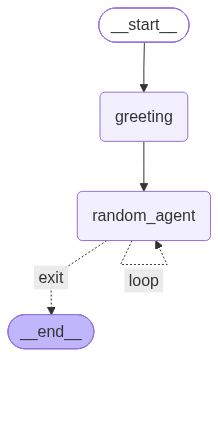

In [7]:
from IPython.display import Image, display

display(Image(app.get_graph().draw_mermaid_png()))

In [10]:
app. invoke({"name":"BOB","number":[],"counter":-1})

{'name': 'hi there, BOB! Welcome to the counter agent.',
 'number': [5, 4, 1, 2, 8],
 'counter': 5}